In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('placement.csv')

In [5]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [6]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Package')

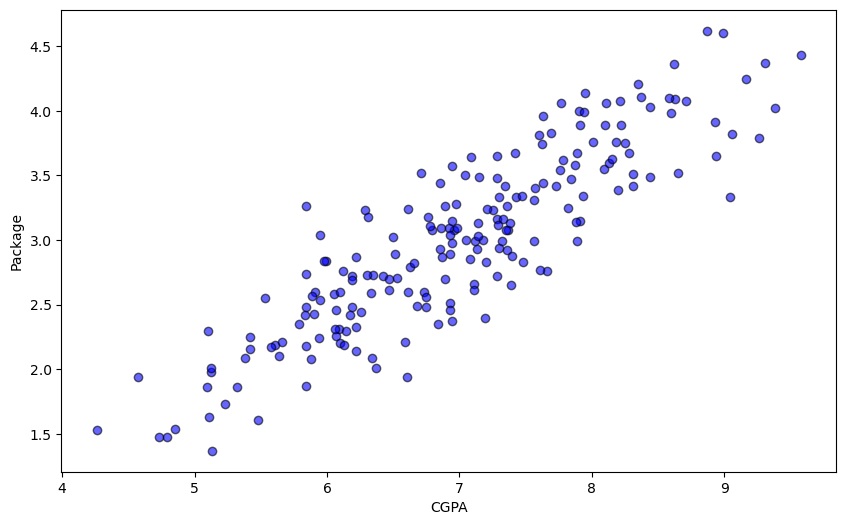

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(df['cgpa'], df['package'], alpha=0.6, c='blue', edgecolors='black')
plt.xlabel('CGPA')
plt.ylabel('Package')

# Using Linear Regression

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [20]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:, 0:1], df.iloc[:, -1], test_size=0.2, random_state=2)

In [21]:
lr = LinearRegression()

In [22]:
lr.fit(x_train, y_train)

LinearRegression()

In [43]:
y_pred = lr.predict(x_test)

In [32]:
print(x_test.values[1])
print(y_test.values[1])

[7.15]
3.49


In [42]:
prediction = lr.predict(x_test.iloc[1].values.reshape(1,1))
print(f"Predicted value: {prediction[0]}")

# Compare with actual value
print(f"Actual value: {y_test.iloc[1]}")

Predicted value: 3.0932446877463504
Actual value: 3.49


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Draw slope (y = mx + b)

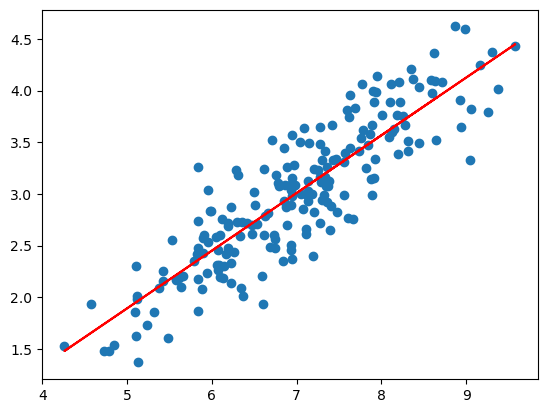

In [47]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(x_train, lr.predict(x_train), color='red')

In [49]:
m = lr.coef_
print(f"Slope: {m}")

Slope: [0.55795197]


In [51]:
b = lr.intercept_

In [55]:
# Extract values once
x_val = df.iloc[0, 0]
y_actual = df.iloc[0, 1]

# Calculate prediction
y_pred = m * x_val + b

# Convert to scalar if array
if hasattr(y_pred, 'item'):
    y_pred = y_pred.item()
if hasattr(y_actual, 'item'):
    y_actual = y_actual.item()

# Print results
print(f"Predicted value for {x_val}: {y_pred}")
print(f"Actual value: {y_actual}")
print(f"Error: {abs(y_pred - y_actual):.4f}")

Predicted value for 6.89: 2.9481771746558314
Actual value: 3.26
Error: 0.3118


In [56]:
b

np.float64(-0.8961119222429144)